# 1. 读取参考重抽样后的结果

之前已经使用 CID4535 完成一次 RCTD，这里检查更换抽到的参考细胞后，各个 spot 的预测是否还一致。

每个细胞类型内部有放回抽样，抽取数量与原来相同，共 10 次，抽样种子为 1001—1010。每轮预处理与拟合前的随机种子固定为 9，使用 full 模式与 2 个 CPU 核心。空间数据、13 类标签和输入共同基因保持相同；RCTD 内部筛选的基因随参考变化，另行记录。

重复抽到同一细胞时，使用新的唯一条码构建对象，原始条码保存在 sampled_cells.csv。每个抽样记录都可以对应回原细胞。本步骤查看单供者内部的参考敏感性，后续统计10次重复的观察范围。

先运行同目录的 rctd_reference_bootstrap.R，再用下面的 notebook 读取全部 10 次拟合结果。

In [1]:
from pathlib import Path
import json
import math

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from IPython.display import display

project_dir = Path("/Users/georicl/Documents/sc_sncell_github")
baseline_dir = project_dir / "data/processed/CID4535_rctd_v1"
bootstrap_dir = project_dir / "data/processed/CID4535_reference_bootstrap_v1"
result_dir = project_dir / "results/CID4535_reference_bootstrap_v1"
seeds = list(range(1001, 1011))

# 必须完成拟合，不能把只有预处理的目录算作一次结果
missing_seeds = [
    seed for seed in seeds
    if not (bootstrap_dir / f"seed_{seed}" / "completed.rds").exists()
]
if missing_seeds:
    raise FileNotFoundError(f"以下重抽样尚未完成拟合：{missing_seeds}。请先运行 R 脚本。")

result_dir.mkdir(parents=True, exist_ok=True)
adata = ad.read_h5ad(
    project_dir / "data/processed/CID4535_spatial/spatial_qc_filtering.h5ad"
)
baseline_raw = pd.read_csv(
    baseline_dir / "rctd_weights_spot_by_celltype.csv", index_col=0
)

raw_runs = {}
run_summaries = []
for seed in seeds:
    run_dir = bootstrap_dir / f"seed_{seed}"
    raw_runs[seed] = pd.read_csv(run_dir / "weights.csv", index_col=0)
    run_summaries.append(pd.read_csv(run_dir / "run_summary.csv"))
run_summary = pd.concat(run_summaries, ignore_index=True)
display(run_summary)


,seed,n_spots,n_types,n_genes_reg,gene_jaccard_vs_baseline,elapsed_seconds
0,1001,1102,13,1754,0.634069,203.315722
1,1002,1102,13,1790,0.565737,203.039887
2,1003,1102,13,1709,0.642359,217.264694
3,1004,1102,13,1568,0.700815,216.165688
4,1005,1102,13,1746,0.613743,292.169557
5,1006,1102,13,1675,0.628495,293.551449
6,1007,1102,13,1568,0.701805,233.589142
7,1008,1102,13,1563,0.649887,234.655072
8,1009,1102,13,1715,0.619525,211.461795
9,1010,1102,13,1885,0.621121,215.932764


# 2. 对齐 spot 与细胞类型，统一计算相对权重

先检查每轮是否覆盖同样的 spot 和细胞类型，再按基线顺序对齐。缺失预测的 spot 会在这一步检查出来。

原始权重单独保留，主要比较逐 spot 归一化后的相对权重。每个 spot 的相对权重之和为 1，表示各类型预测权重在该 spot 内的占比。

In [2]:
def check_weights(frame):
    assert frame.index.is_unique and frame.columns.is_unique
    assert np.isfinite(frame.to_numpy()).all()
    assert (frame.to_numpy() >= 0).all()
    assert (frame.sum(axis=1) > 0).all()

check_weights(baseline_raw)
assert set(baseline_raw.index) == set(adata.obs_names)
baseline_raw = baseline_raw.loc[adata.obs_names]

for seed, frame in raw_runs.items():
    check_weights(frame)
    assert set(frame.index) == set(baseline_raw.index), f"{seed} 的 spot 范围变化"
    assert set(frame.columns) == set(baseline_raw.columns), f"{seed} 的参考类型变化"
    raw_runs[seed] = frame.loc[baseline_raw.index, baseline_raw.columns]

baseline = baseline_raw.div(baseline_raw.sum(axis=1), axis=0)
runs = {
    seed: frame.div(frame.sum(axis=1), axis=0)
    for seed, frame in raw_runs.items()
}
cell_types = baseline.columns.tolist()
targets = ["CAFs", "T cells CD8+", "PVL", "Cancer Epithelial"]
print("基线大小：", baseline.shape)
print("完整重复次数：", len(runs))


基线大小： (1102, 13)
完整重复次数： 10


# 3. 比较权重与空间排序是否稳定

每个类型分别比较 10 次结果与基线，Spearman 相关查看 spot 高低排序，数值变化的一致程度用 Pearson 相关表示，MAE 记录平均绝对差异。

MAE 乘以 100 后记为相对权重的百分点。同时保留偏移量、MAE 和第 95 百分位绝对误差，查看排序和数值的变化。原始权重的差异也单独保存。

In [3]:
metric_rows = []
for seed, frame in runs.items():
    for cell_type in cell_types:
        base_values = baseline[cell_type].to_numpy()
        values = frame[cell_type].to_numpy()
        delta = values - base_values
        raw_delta = (
            raw_runs[seed][cell_type] - baseline_raw[cell_type]
        ).to_numpy()
        metric_rows.append({
            "seed": seed,
            "cell_type": cell_type,
            "spearman": spearmanr(base_values, values).statistic,
            "pearson": pearsonr(base_values, values).statistic,
            "mae_pp": np.abs(delta).mean() * 100,
            "bias_pp": delta.mean() * 100,
            "p95_abs_error_pp": np.quantile(np.abs(delta), 0.95) * 100,
            "raw_weight_mae": np.abs(raw_delta).mean(),
        })
metrics = pd.DataFrame(metric_rows)
summary = metrics.groupby("cell_type", sort=False).agg(
    spearman_median=("spearman", "median"),
    spearman_min=("spearman", "min"),
    mae_pp_median=("mae_pp", "median"),
    mae_pp_max=("mae_pp", "max"),
    bias_pp_median=("bias_pp", "median"),
)
metrics.to_csv(result_dir / "metrics_by_run.csv", index=False)
summary.to_csv(result_dir / "stability_summary.csv")
display(summary.loc[targets].round(4))


,spearman_median,spearman_min,mae_pp_median,mae_pp_max,bias_pp_median
cell_type,,,,,
CAFs,0.9957,0.9926,0.4622,0.8036,-0.3635
T cells CD8+,0.8536,0.7578,0.6091,1.3650,0.2988
PVL,0.9450,0.9295,0.1379,0.1706,-0.0332
Cancer Epithelial,0.9954,0.9944,1.4621,2.5843,0.8703


# 4. 检查高值 spot 是否仍然是同一批

分别取每类权重排序前 5%、10%、20% 的 spot，比较重合比例。这里按权重排名定义高值集合。

固定取 ceil(比例 × spot数) 个 spot；同值时按条码排序，保证重复计算一致。Jaccard 为交集/并集，保留率为交集/基线高值集合数。每轮集合大小相同，两者分别用并集和基线集合表示这批 spot 的重合程度。

In [4]:
def high_spots(series, fraction):
    n_top = math.ceil(len(series) * fraction)
    ranked = (
        series.rename("weight").rename_axis("barcode").reset_index()
        .sort_values(["weight", "barcode"], ascending=[False, True])
    )
    return set(ranked.head(n_top)["barcode"])

overlap_rows = []
for cell_type in cell_types:
    for fraction in [0.05, 0.10, 0.20]:
        base_set = high_spots(baseline[cell_type], fraction)
        for seed, frame in runs.items():
            new_set = high_spots(frame[cell_type], fraction)
            shared = len(base_set & new_set)
            overlap_rows.append({
                "seed": seed, "cell_type": cell_type,
                "top_fraction": fraction, "n_top": len(base_set),
                "n_overlap": shared,
                "retention": shared / len(base_set),
                "jaccard": shared / len(base_set | new_set),
            })
overlaps = pd.DataFrame(overlap_rows)
overlaps.to_csv(result_dir / "high_spot_overlap.csv", index=False)
display(
    overlaps[overlaps["top_fraction"].eq(0.10)]
    .groupby("cell_type")[["retention", "jaccard"]]
    .agg(["median", "min", "max"]).loc[targets].round(3)
)


retention               jaccard              
                     median    min    max  median    min    max
cell_type                                                      
CAFs                  0.955  0.946  0.973   0.914  0.897  0.947
T cells CD8+          0.802  0.766  0.847   0.669  0.620  0.734
PVL                   0.914  0.892  0.937   0.842  0.805  0.881
Cancer Epithelial     0.793  0.766  0.820   0.657  0.620  0.695

# 5. 计算每个 spot 的变化和高值出现频率

逐 spot 计算重复结果的平均值和标准差，同时记录观察到的最小值与最大值。这里汇总 10 次参考重抽样的变化。

高值出现频率为该 spot 在 10 次中进入前 10% 的次数/10，用于查看抽样后的排名稳定性。

In [5]:
cube = np.stack([runs[seed].to_numpy() for seed in seeds])
mean_weights = pd.DataFrame(cube.mean(axis=0), index=baseline.index, columns=cell_types)
sd_weights = pd.DataFrame(cube.std(axis=0, ddof=1), index=baseline.index, columns=cell_types)
frequency = pd.DataFrame(0.0, index=baseline.index, columns=cell_types)
for frame in runs.values():
    for cell_type in cell_types:
        ids = list(high_spots(frame[cell_type], 0.10))
        frequency.loc[ids, cell_type] += 1 / len(runs)

spot_tables = []
for j, cell_type in enumerate(cell_types):
    spot_tables.append(pd.DataFrame({
        "barcode": baseline.index, "cell_type": cell_type,
        "baseline": baseline[cell_type].to_numpy(),
        "bootstrap_mean": mean_weights[cell_type].to_numpy(),
        "bootstrap_sd": sd_weights[cell_type].to_numpy(),
        "observed_min": cube[:, :, j].min(axis=0),
        "observed_max": cube[:, :, j].max(axis=0),
        "top10_frequency": frequency[cell_type].to_numpy(),
    }))
spot_metrics = pd.concat(spot_tables, ignore_index=True)
spot_metrics.to_csv(result_dir / "spot_stability.csv", index=False)
display(spot_metrics[spot_metrics["cell_type"].eq("T cells CD8+")].head())


,barcode,cell_type,baseline,bootstrap_mean,bootstrap_sd,observed_min,observed_max,top10_frequency
13224,AACATTGGTCAGCCGT-1,T cells CD8+,0.019955,0.017320,0.019830,0.000087,0.048368,0.0
13225,CATCGAATGGATCTCT-1,T cells CD8+,0.000062,0.000070,0.000015,0.000059,0.000092,0.0
13226,GCGTCCAGCTCGTGGC-1,T cells CD8+,0.000061,0.002771,0.003633,0.000059,0.008605,0.0
13227,CCAAAGTCCCGCTAAC-1,T cells CD8+,0.000083,0.001538,0.003154,0.000057,0.008880,0.0
13228,GTTACGGCCCGACTGC-1,T cells CD8+,0.000084,0.000746,0.001470,0.000082,0.004372,0.0


# 6. 把稳定性放回组织图像上看

每行依次显示基线、重抽样平均值、标准差和前 10% 出现频率。基线与均值共用同一个色阶；CAF 与 CD8 的权重色阶分别设置，跨行查看时按各自色条读取数值。

颜色上限取基线与重抽样均值合并后的第 99 百分位，超过上限显示为最高颜色，原始数值不改动。标准差使用独立色阶并以百分点表示。

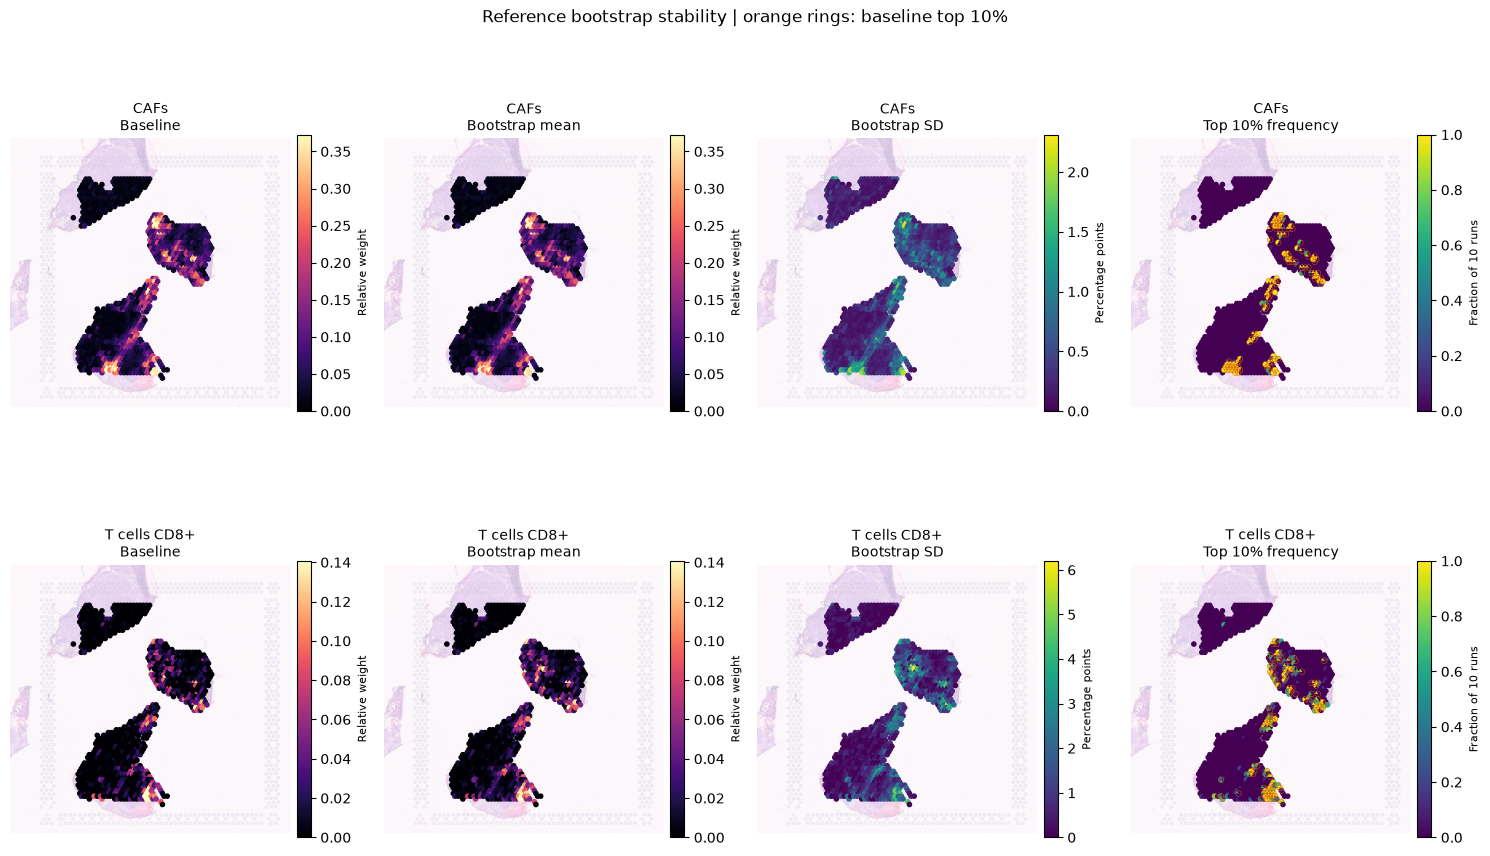

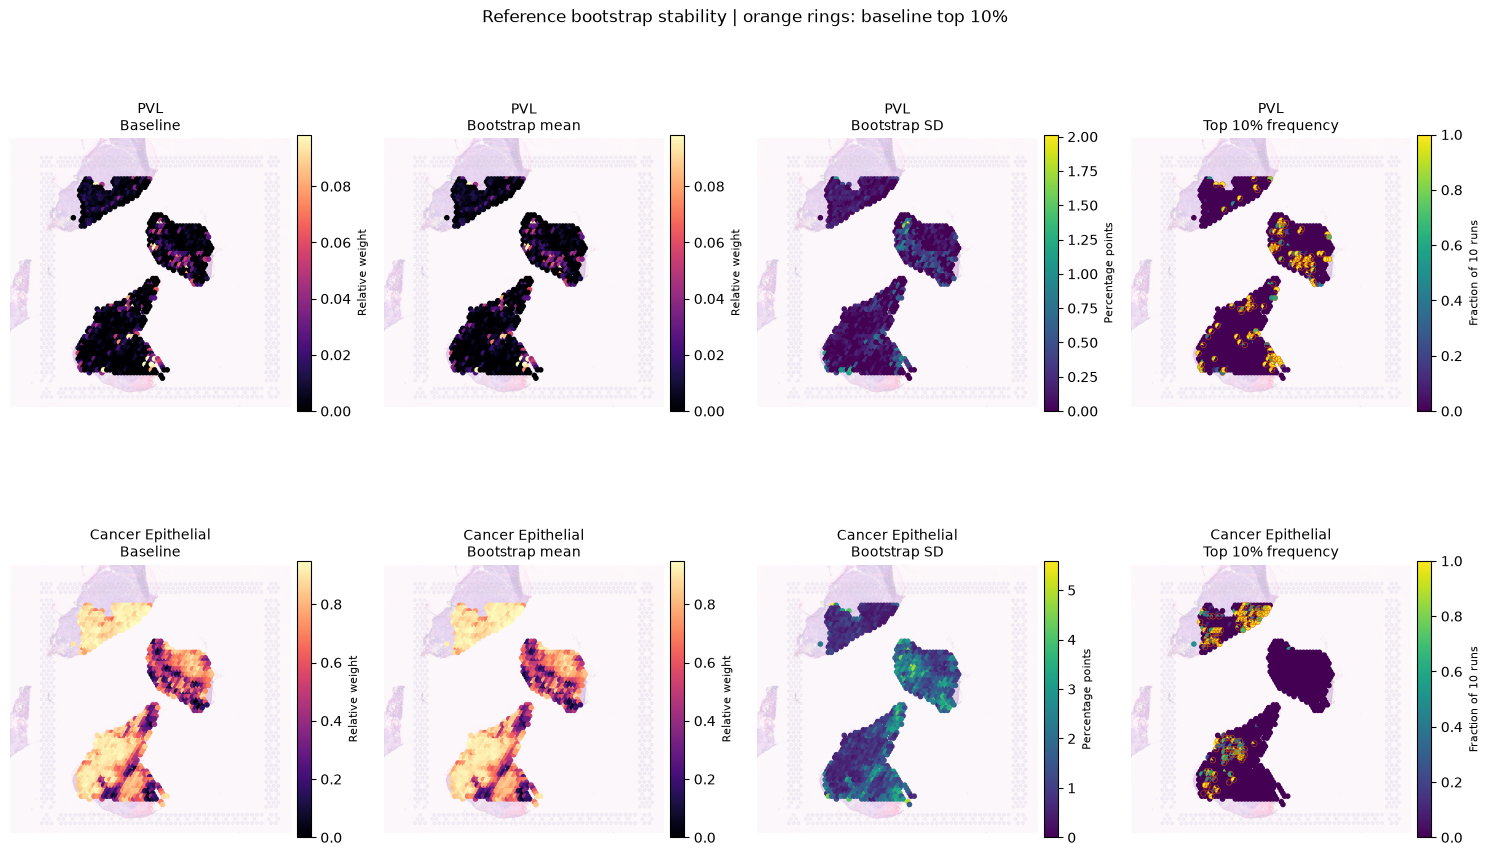

In [6]:
spatial = adata.uns["spatial"]["CID4535"]
xy = adata.obsm["spatial"] * spatial["scalefactors"]["tissue_hires_scalef"]
image = spatial["images"]["hires"]

def draw_stability_maps(types, filename):
    fig, axes = plt.subplots(len(types), 4, figsize=(15, 4.8 * len(types)), squeeze=False)
    for i, cell_type in enumerate(types):
        limit = float(np.quantile(
            np.r_[baseline[cell_type], mean_weights[cell_type]], 0.99
        ))
        panels = [
            (baseline[cell_type], "Baseline", "magma", limit, "Relative weight"),
            (mean_weights[cell_type], "Bootstrap mean", "magma", limit, "Relative weight"),
            (sd_weights[cell_type] * 100, "Bootstrap SD", "viridis", None, "Percentage points"),
            (frequency[cell_type], "Top 10% frequency", "viridis", 1, "Fraction of 10 runs"),
        ]
        for j, (values, title, cmap, upper, unit) in enumerate(panels):
            ax = axes[i, j]
            ax.imshow(image, alpha=0.25)
            points = ax.scatter(xy[:, 0], xy[:, 1], c=values, s=9,
                                cmap=cmap, vmin=0, vmax=upper)
            ax.set_title(f"{cell_type}\n{title}", fontsize=10)
            ax.set_axis_off()
            bar = fig.colorbar(points, ax=ax, fraction=0.046, pad=0.02)
            bar.set_label(unit, fontsize=8)
        # 基线高值的位置用细圈标记在频率图，便于观察原来的热点是否保留
        is_high = baseline.index.isin(high_spots(baseline[cell_type], 0.10))
        axes[i, 3].scatter(xy[is_high, 0], xy[is_high, 1], s=16,
                           facecolors="none", edgecolors="#d45b00", linewidths=0.35)
    fig.suptitle("Reference bootstrap stability | orange rings: baseline top 10%", fontsize=12)
    fig.tight_layout()
    fig.savefig(result_dir / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(result_dir / f"{filename}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

draw_stability_maps(["CAFs", "T cells CD8+"], "caf_cd8_spatial_stability")
draw_stability_maps(["PVL", "Cancer Epithelial"], "pvl_cancer_spatial_stability")


# 7. 汇总各次运行的指标

将每轮作为一个点，展示不同抽样之间的波动。这里按10次重抽样汇总指标。

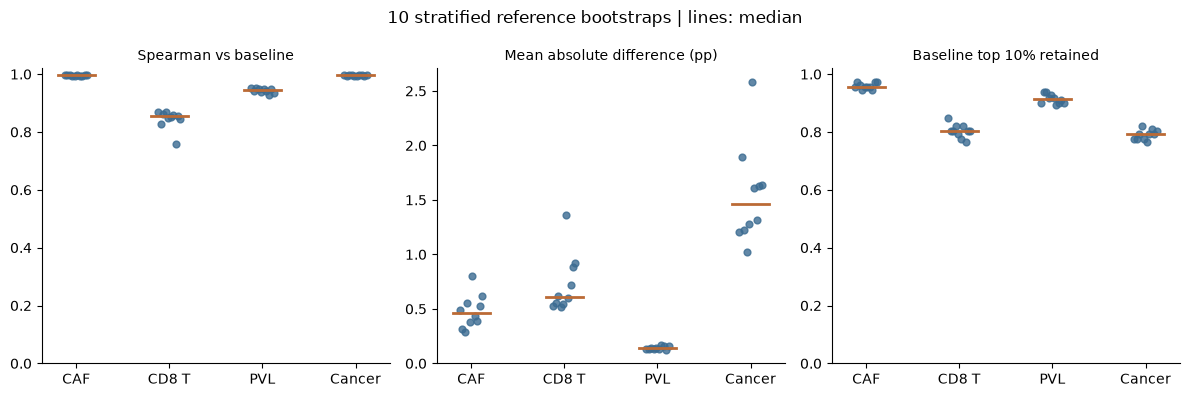

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
top10 = overlaps[overlaps["top_fraction"].eq(0.10)]
panels = [
    (metrics, "spearman", "Spearman vs baseline"),
    (metrics, "mae_pp", "Mean absolute difference (pp)"),
    (top10, "retention", "Baseline top 10% retained"),
]
for ax, (table, metric, title) in zip(axes, panels):
    for i, cell_type in enumerate(targets):
        values = table.loc[table["cell_type"].eq(cell_type), metric].to_numpy()
        ax.scatter(i + np.linspace(-0.12, 0.12, len(values)), values,
                   s=24, color="#3b6b91", alpha=0.8)
        ax.plot([i - 0.2, i + 0.2], [np.median(values)] * 2, color="#bb6a35", lw=2)
    ax.set_xticks(range(len(targets)), ["CAF", "CD8 T", "PVL", "Cancer"])
    ax.set_title(title, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    if metric in ["spearman", "retention"]:
        ax.set_ylim(min(0, table[metric].min() - 0.05), 1.02)
    else:
        ax.set_ylim(bottom=0)
fig.suptitle("10 stratified reference bootstraps | lines: median")
fig.tight_layout()
fig.savefig(result_dir / "stability_metrics.png", dpi=300)
fig.savefig(result_dir / "stability_metrics.pdf")
plt.show()


# 8. 核对区域分布和 CAF—CD8 关系是否改变

沿用作者病理标签，逐区域统计相对权重中位数。CAF—CD8 相关按全切片计算，用于查看两类权重的共同变化，其中包含空间结构与组成约束的影响。

In [8]:
pathology = adata.obs["Classification"].astype("string").fillna("Missing")
region_rows = []
association_rows = []
for run_id, frame in [("baseline", baseline)] + [(str(s), runs[s]) for s in seeds]:
    regions = frame[targets].copy()
    regions["pathology"] = pathology
    region_table = regions.groupby("pathology")[targets].median().reset_index()
    region_table.insert(0, "run", run_id)
    region_rows.append(region_table)
    association_rows.append({
        "run": run_id,
        "caf_cd8_spearman": spearmanr(frame["CAFs"], frame["T cells CD8+"]).statistic,
    })
regions = pd.concat(region_rows, ignore_index=True)
associations = pd.DataFrame(association_rows)
regions.to_csv(result_dir / "pathology_region_medians.csv", index=False)
associations.to_csv(result_dir / "caf_cd8_association.csv", index=False)
display(associations.round(4))
display(regions[regions["pathology"].isin(["Stroma", "Invasive cancer", "Lymphocytes"])])


,run,caf_cd8_spearman
0,baseline,0.6100
1,1001,0.6013
2,1002,0.5757
3,1003,0.6377
4,1004,0.5687
5,1005,0.5851
6,1006,0.6858
7,1007,0.6789
8,1008,0.5967
9,1009,0.6894


,run,pathology,CAFs,T cells CD8+,PVL,Cancer Epithelial
1,baseline,Invasive cancer,0.027521,0.000128,0.000134,0.859004
4,baseline,Lymphocytes,0.068310,0.021510,0.000413,0.404430
6,baseline,Stroma,0.142113,0.010565,0.000206,0.500306
9,1001,Invasive cancer,0.025420,0.002100,0.000135,0.853034
12,1001,Lymphocytes,0.062248,0.033247,0.000314,0.423041
14,1001,Stroma,0.132530,0.016225,0.000211,0.497161
17,1002,Invasive cancer,0.027247,0.001609,0.000181,0.863964
20,1002,Lymphocytes,0.073220,0.032639,0.001467,0.428099
22,1002,Stroma,0.136404,0.012899,0.000214,0.529331
25,1003,Invasive cancer,0.026618,0.000138,0.000134,0.858733


# 9. 解读本轮结果并保存记录

结合排序、数值差异和高值区域重合三方面查看。排序稳定而 MAE 较大时，位置相似但权重有偏移；全体 spot 的 MAE 很小，也可能是因为大多数 spot 接近零，所以还要看前 10% 高值集合。

下面汇总 10 次拟合的实际输出，保存各项数值和本轮运行记录。

In [9]:
lines = [
    "# CID4535 参考重抽样稳定性结果",
    "",
    "共10次按参考类型分层的有放回重抽样。参考供者为CID4535，空间spot和标签保持一致。",
    "每轮拟合种子固定为9；full模式、2核心、ref_UMI_min=100、ref_n_cells_min=15。",
    "输入共同基因固定，模型内部基因筛选随参考重新执行。",
    "",
    "## 1. 权重与高值位置的变化",
    "",
]
for cell_type in targets:
    sub = metrics[metrics["cell_type"].eq(cell_type)]
    hot = top10[top10["cell_type"].eq(cell_type)]
    ids = list(high_spots(baseline[cell_type], 0.10))
    stable_count = int((frequency.loc[ids, cell_type] >= 0.8 - 1e-10).sum())
    lines.append(
        f"- {cell_type}：Spearman中位数{sub.spearman.median():.3f}"
        f"（范围{sub.spearman.min():.3f}—{sub.spearman.max():.3f}）；"
        f"MAE中位数{sub.mae_pp.median():.3f}个百分点；"
        f"基线前10% spot保留率中位数{hot.retention.median():.1%}；"
        f"基线高值spot中{stable_count}/{len(ids)}个在至少8/10次仍处于前10%。"
    )
lines += [
    "",
    "## 2. 全切片CAF与CD8的描述性关系",
    "",
    f"基线相关为{associations.iloc[0].caf_cd8_spearman:.3f}；"
    f"重抽样范围为{associations.iloc[1:].caf_cd8_spearman.min():.3f}—"
    f"{associations.iloc[1:].caf_cd8_spearman.max():.3f}。",
    "",
    "各项范围记录10次参考重抽样的观察值；高值频率记录每个spot进入前10%的次数占比。",
    "本轮按同供者细胞重抽样统计参考敏感性，后续结合供者隔离的已知组成测试和独立病理信息继续核对。",
]
report = "\n".join(lines)
(result_dir / "interpretation.md").write_text(report, encoding="utf-8")
print(report)
run_summary.to_csv(result_dir / "run_summary.csv", index=False)
(result_dir / "analysis_parameters.json").write_text(
    json.dumps({
        "bootstrap_seeds": seeds, "fit_seed": 9, "top_fractions": [0.05, 0.10, 0.20],
        "n_bootstraps": len(seeds), "normalization": "per-spot sum of raw weights",
        "error_units": "percentage points of relative weight",
        "uncertainty": "observed bootstrap spread, not confidence interval",
    }, indent=2), encoding="utf-8"
)


# CID4535 参考重抽样稳定性结果

共10次按参考类型分层的有放回重抽样。参考供者为CID4535，空间spot和标签保持一致。
每轮拟合种子固定为9；full模式、2核心、ref_UMI_min=100、ref_n_cells_min=15。
输入共同基因固定，模型内部基因筛选随参考重新执行。

## 1. 权重与高值位置的变化

- CAFs：Spearman中位数0.996（范围0.993—0.997）；MAE中位数0.462个百分点；基线前10% spot保留率中位数95.5%；基线高值spot中102/111个在至少8/10次仍处于前10%。
- T cells CD8+：Spearman中位数0.854（范围0.758—0.869）；MAE中位数0.609个百分点；基线前10% spot保留率中位数80.2%；基线高值spot中76/111个在至少8/10次仍处于前10%。
- PVL：Spearman中位数0.945（范围0.929—0.954）；MAE中位数0.138个百分点；基线前10% spot保留率中位数91.4%；基线高值spot中95/111个在至少8/10次仍处于前10%。
- Cancer Epithelial：Spearman中位数0.995（范围0.994—0.997）；MAE中位数1.462个百分点；基线前10% spot保留率中位数79.3%；基线高值spot中71/111个在至少8/10次仍处于前10%。

## 2. 全切片CAF与CD8的描述性关系

基线相关为0.610；重抽样范围为0.569—0.689。

各项范围记录10次参考重抽样的观察值；高值频率记录每个spot进入前10%的次数占比。
本轮按同供者细胞重抽样统计参考敏感性，后续结合供者隔离的已知组成测试和独立病理信息继续核对。


399